In [2]:
# ─── Импорты и настройки ──────────────────────────────────
import os
import re
import random
import warnings
from typing import List, Dict, Tuple, Optional

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import faiss
from sentence_transformers import SentenceTransformer

from IPython.display import display, Markdown

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

# Воспроизводимость
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

set_seed(42)
warnings.filterwarnings("ignore")

# Устройство
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print(f"Устройство: {DEVICE}")
print(f"sentence-transformers ready")

NumPy: 1.26.4
Pandas: 3.0.1
FAISS available: True
Устройство: cuda
sentence-transformers ready


In [3]:
# ─── 2.3.2. База знаний: Финансовый глоссарий ─────────────────
from typing import List, Dict

documents: List[Dict[str, str]] = [
    {
        "doc_id": "fin_01",
        "title": "Диверсификация",
        "text": (
            "Диверсификация — стратегия распределения капитала между различными активами, "
            "секторами экономики или географическими регионами с целью снижения риска. "
            "Основная идея: не класть все яйца в одну корзину. При диверсификации убытки по одним "
            "инвестициям могут компенсироваться прибылью по другим, что делает портфель более устойчивым."
        ),
    },
    {
        "doc_id": "fin_02",
        "title": "Сложный процент",
        "text": (
            "Сложный процент — метод начисления процентов, при котором проценты добавляются "
            "к основной сумме вклада, и в следующий период проценты начисляются уже на увеличенную сумму. "
            "Это позволяет капиталу расти экспоненциально со временем. Формула: A = P(1 + r/n)^(nt), "
            "где P — начальная сумма, r — ставка, n — число начислений в год, t — срок в годах."
        ),
    },
    {
        "doc_id": "fin_03",
        "title": "Инфляция",
        "text": (
            "Инфляция — устойчивое повышение общего уровня цен на товары и услуги в экономике. "
            "При инфляции покупательная способность денег снижается: на ту же сумму можно купить меньше. "
            "Умеренная инфляция (2–4% в год) считается нормальной, высокая инфляция разрушает сбережения. "
            "Для защиты от инфляции инвесторы вкладывают средства в активы, которые растут быстрее инфляции."
        ),
    },
    {
        "doc_id": "fin_04",
        "title": "Ликвидность",
        "text": (
            "Ликвидность — способность актива быть быстро проданным по цене, близкой к рыночной, "
            "без существенной потери стоимости. Деньги — самый ликвидный актив. Недвижимость — низколиквидна, "
            "так как её продажа может занять месяцы. Высокая ликвидность важна для экстренного доступа к средствам."
        ),
    },
    {
        "doc_id": "fin_05",
        "title": "Волатильность",
        "text": (
            "Волатильность — мера изменчивости цены актива за определённый период. Высокая волатильность "
            "означает большие колебания цены (как вверх, так и вниз), что увеличивает как потенциальную прибыль, "
            "так и риск убытков. Волатильность часто измеряют через стандартное отклонение доходности. "
            "Акции обычно более волатильны, чем облигации."
        ),
    },
    {
        "doc_id": "fin_06",
        "title": "Дивиденды",
        "text": (
            "Дивиденды — часть прибыли компании, которая распределяется между акционерами. "
            "Выплачиваются в денежной форме или дополнительными акциями. Дивидендная доходность = "
            "(годовые дивиденды / цена акции) × 100%. Компании могут выплачивать дивиденды ежеквартально, "
            "раз в полгода или ежегодно. Не все компании платят дивиденды: некоторые реинвестируют прибыль в рост."
        ),
    },
    {
        "doc_id": "fin_07",
        "title": "Облигации",
        "text": (
            "Облигация — долговая ценная бумага, по которой эмитент (компания или государство) обязуется "
            "вернуть инвестору номинальную стоимость в определённый срок и выплачивать процентный доход (купон). "
            "Облигации считаются менее рискованными, чем акции, но и приносят меньшую потенциальную доходность. "
            "Государственные облигации (ОФЗ в РФ) — самые надёжные."
        ),
    },
    {
        "doc_id": "fin_08",
        "title": "Акции",
        "text": (
            "Акция — ценная бумага, подтверждающая долю владения в компании. Владелец акции (акционер) "
            "имеет право на часть прибыли (дивиденды) и участие в управлении (голосование на собраниях). "
            "Цена акции определяется спросом и предложением на бирже. Инвестиции в акции потенциально "
            "приносят высокую доходность, но сопряжены с высоким риском."
        ),
    },
    {
        "doc_id": "fin_09",
        "title": "ИИС (Индивидуальный инвестиционный счёт)",
        "text": (
            "ИИС — специальный брокерский счёт, который предоставляет налоговые льготы для стимулирования "
            "долгосрочных инвестиций в России. Существует два типа вычетов: тип А (возврат 13% от внесённой суммы, "
            "до 52 000 ₽ в год) и тип Б (освобождение от налога на доход от инвестиций). Срок счёта — минимум 3 года."
        ),
    },
    {
        "doc_id": "fin_10",
        "title": "Подушка безопасности",
        "text": (
            "Подушка безопасности — резерв денежных средств, предназначенный для покрытия непредвиденных расходов "
            "или потери дохода. Рекомендуемый размер: 3–6 месяцев текущих расходов. Хранить подушку следует "
            "в высоколиквидных и низкорисковых инструментах: накопительный счёт, вклад с возможностью снятия. "
            "Это основа финансовой устойчивости перед началом инвестирования."
        ),
    },
    {
        "doc_id": "fin_11",
        "title": "Бюджетирование",
        "text": (
            "Бюджетирование — процесс планирования доходов и расходов на определённый период (месяц, год). "
            "Помогает контролировать траты, достигать финансовых целей и избегать долгов. Популярные методы: "
            "правило 50/30/20 (50% — обязательные расходы, 30% — желания, 20% — сбережения), "
            "метод конвертов, ведение таблицы или приложения для учёта финансов."
        ),
    },
    {
        "doc_id": "fin_12",
        "title": "Ребалансировка портфеля",
        "text": (
            "Ребалансировка — периодическое приведение структуры инвестиционного портфеля к целевому распределению "
            "активов. Например, если целевое соотношение акций/облигаций 70/30, а из-за роста акций стало 85/15, "
            "инвестор продаёт часть акций и докупает облигации. Ребалансировка помогает контролировать риск "
            "и дисциплинированно фиксировать прибыль. Проводится раз в 6–12 месяцев."
        ),
    },
    {
        "doc_id": "fin_13",
        "title": "Риск-профиль инвестора",
        "text": (
            "Риск-профиль — характеристика, отражающая готовность и способность инвестора принимать финансовые риски. "
            "Выделяют консервативный (минимальный риск, низкая доходность), умеренный (баланс риска и доходности) "
            "и агрессивный (высокий риск, потенциально высокая доходность) профили. Определяется через анкетирование "
            "у брокера и влияет на рекомендуемые инвестиционные стратегии."
        ),
    },
    {
        "doc_id": "fin_14",
        "title": "Налоговый вычет",
        "text": (
            "Налоговый вычет — сумма, на которую уменьшается налогооблагаемая база или возвращается часть уплаченного НДФЛ. "
            "В инвестициях применяются: вычет по ИИС (тип А), вычет на долгосрочное владение ценными бумагами (ЛДВ), "
            "вычет на убытки от операций с ценными бумагами. Для получения вычета нужно подать декларацию 3-НДФЛ "
            "в налоговую инспекцию или через брокера."
        ),
    },
    {
        "doc_id": "fin_15",
        "title": "Валютный риск",
        "text": (
            "Валютный риск — вероятность убытков из-за неблагоприятного изменения курса иностранной валюты. "
            "Возникает при инвестициях в зарубежные активы или хранении сбережений в валюте. "
            "Для снижения риска используют хеджирование (форварды, опционы) или диверсификацию по валютам. "
            "Ослабление рубля выгодно экспортёрам, укрепление — импортёрам и тем, кто покупает зарубежные товары."
        ),
    },
]

# ─── Sanity-check: проверка базы знаний ───────────────────────
import pandas as pd
from IPython.display import display

docs_df = pd.DataFrame(documents)
print(f"Размер базы: {len(docs_df)} документов")
print(f"Поля: {list(docs_df.columns)}")
print(f"\nПримеры документов:")
display(docs_df[["doc_id", "title"]])

# Показать один документ целиком для примера
print(f"\n Пример текста (документ {docs_df.iloc[0]['doc_id']}):")
print(f"Заголовок: {docs_df.iloc[0]['title']}")
print(f"Текст: {docs_df.iloc[0]['text'][:200]}...")

Размер базы: 15 документов
Поля: ['doc_id', 'title', 'text']

Примеры документов:


,doc_id,title
0,fin_01,Диверсификация
1,fin_02,Сложный процент
2,fin_03,Инфляция
3,fin_04,Ликвидность
4,fin_05,Волатильность
5,fin_06,Дивиденды
6,fin_07,Облигации
7,fin_08,Акции
8,fin_09,ИИС (Индивидуальный инвестиционный счёт)
9,fin_10,Подушка безопасности



 Пример текста (документ fin_01):
Заголовок: Диверсификация
Текст: Диверсификация — стратегия распределения капитала между различными активами, секторами экономики или географическими регионами с целью снижения риска. Основная идея: не класть все яйца в одну корзину....


In [4]:
# ─── Контрольные запросы для benchmark ────────────────────────
benchmark_queries = [
    {"query": "Что такое диверсификация и зачем она нужна?", "relevant_doc_ids": ["fin_01"]},
    {"query": "Как работает сложный процент?", "relevant_doc_ids": ["fin_02"]},
    {"query": "Почему инфляция снижает покупательную способность?", "relevant_doc_ids": ["fin_03"]},
    {"query": "Какой актив самый ликвидный?", "relevant_doc_ids": ["fin_04"]},
    {"query": "Что означает высокая волатильность акции?", "relevant_doc_ids": ["fin_05"]},
    {"query": "Как компания выплачивает дивиденды?", "relevant_doc_ids": ["fin_06"]},
    {"query": "Чем облигация отличается от акции?", "relevant_doc_ids": ["fin_07", "fin_08"]},
    {"query": "Какие налоговые льготы даёт ИИС?", "relevant_doc_ids": ["fin_09"]},
    {"query": "Сколько денег должно быть в подушке безопасности?", "relevant_doc_ids": ["fin_10"]},
    {"query": "Как вести бюджет по правилу 50/30/20?", "relevant_doc_ids": ["fin_11"]},
    {"query": "Зачем нужна ребалансировка портфеля?", "relevant_doc_ids": ["fin_12"]},
    {"query": "Какие бывают типы риск-профилей?", "relevant_doc_ids": ["fin_13"]},
]

### База знаний: Финансовый глоссарий

**Предметная область:** Личные финансы и инвестиции  
**Объём:** 15 документов (терминов), ~40–70 слов каждый (~200–400 символов)  
**Язык:** Русский  
**Почему эта тема подходит для retrieval:**
- Чёткие определения → легко оценить, найден ли нужный термин
- Термины семантически различны → меньше путаницы при поиске
- Запросы естественны для пользователей («Что такое...?», «Как работает...?»)
- Короткие тексты → не требуется сложный чанкинг, можно тестировать разные параметры
- Подходит для демонстрации влияния обновления базы (добавление новых терминов)

**Источники определений:** адаптировано из открытых образовательных материалов (FinCult, Investopedia, Википедия) с сокращением до ключевых формулировок.

In [5]:
# Инициализация модели
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray: raise NotImplementedError
    def encode_queries(self, texts: List[str]) -> np.ndarray: raise NotImplementedError

class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(texts, batch_size=16, show_progress_bar=False, 
                                    convert_to_numpy=True, normalize_embeddings=True)
        return vectors.astype("float32")
    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(texts, batch_size=16, show_progress_bar=False, 
                                    convert_to_numpy=True, normalize_embeddings=True)
        return vectors.astype("float32")

class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms
    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

def build_embedding_backend(model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", 
                            device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print(f" Используем dense-эмбеддинги: {backend.backend_name}")
        return backend
    except Exception as e:
        print(f" Dense-модель недоступна, переключаемся на TF-IDF. Причина: {repr(e)}")
        return TfidfFallbackBackend()

# Инициализируем модель ДО чанкинга
embedder = build_embedding_backend(device=DEVICE)

# Чанкинг
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 5) -> List[str]:
    words = text.split()
    if not words: return []
    chunks, step = [], chunk_size - overlap
    for start in range(0, len(words), step):
        chunk = " ".join(words[start:start + chunk_size])
        if not chunk: continue
        chunks.append(chunk)
        if start + chunk_size >= len(words): break
    return chunks

def build_chunks_dataframe(docs: List[Dict[str, str]], chunk_size: int = 30, overlap: int = 5) -> pd.DataFrame:
    rows = []
    for doc in docs:
        for idx, chunk in enumerate(chunk_text(doc["text"], chunk_size, overlap)):
            rows.append({
                "doc_id": doc["doc_id"], "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{idx:02d}",
                "chunk_text": chunk, "n_words": len(chunk.split())
            })
    return pd.DataFrame(rows)

# Применяем чанкинг
chunks_df = build_chunks_dataframe(documents, chunk_size=30, overlap=5)
print(f" Документов: {len(documents)} →  Чанков: {len(chunks_df)}")

# Векторизация чанков
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print(f" Матрица эмбеддингов: {chunk_embeddings.shape}")
print(f" Нормы векторов: мин={np.linalg.norm(chunk_embeddings, axis=1).min():.4f}, "
      f"макс={np.linalg.norm(chunk_embeddings, axis=1).max():.4f}")

# FAISS индекс
class VectorSearchIndex:
    def __init__(self, dim: int):
        self.dim = dim
        self._faiss_index = faiss.IndexFlatIP(dim) if faiss else None
        self.backend_name = "FAISS IndexFlatIP" if faiss else "sklearn fallback"
    def add(self, vectors: np.ndarray):
        if self._faiss_index: self._faiss_index.add(vectors.astype("float32"))
    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        if self._faiss_index:
            return self._faiss_index.search(query_vectors.astype("float32"), top_k)
        # fallback на sklearn (упрощённо)
        from sklearn.metrics.pairwise import cosine_similarity
        scores = cosine_similarity(query_vectors, chunk_embeddings)[0]
        indices = np.argsort(-scores)[:top_k]
        return scores[indices], indices

search_index = VectorSearchIndex(chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)
print(f"Индекс построен: {search_index.backend_name}")

# Функция поиска
def search_similar_chunks(query: str, top_k: int = 3) -> pd.DataFrame:
    query_vec = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vec, top_k)
    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = chunks_df.iloc[int(idx)].copy()
        rows.append({"rank": rank, "score": round(float(score), 4), **row.to_dict()})
    return pd.DataFrame(rows)

# Демонстрация поиска
test_queries = [
    "Что такое диверсификация?",
    "Как работает сложный процент?",
    "Почему инфляция снижает покупательную способность?"
]

for q in test_queries:
    display(Markdown(f"### Запрос: {q}"))
    display(search_similar_chunks(q, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

 Используем dense-эмбеддинги: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
 Документов: 15 →  Чанков: 31
 Матрица эмбеддингов: (31, 384)
 Нормы векторов: мин=1.0000, макс=1.0000
Индекс построен: FAISS IndexFlatIP


### Запрос: Что такое диверсификация?

,rank,score,doc_id,title,chunk_text
0,1,0.7962,fin_01,Диверсификация,Диверсификация — стратегия распределения капит...
1,2,0.4605,fin_01,Диверсификация,корзину. При диверсификации убытки по одним ин...
2,3,0.4560,fin_15,Валютный риск,"используют хеджирование (форварды, опционы) ил..."


### Запрос: Как работает сложный процент?

,rank,score,doc_id,title,chunk_text
0,1,0.7302,fin_02,Сложный процент,"Сложный процент — метод начисления процентов, ..."
1,2,0.5311,fin_02,Сложный процент,позволяет капиталу расти экспоненциально со вр...
2,3,0.4661,fin_11,Бюджетирование,"(50% — обязательные расходы, 30% — желания, 20..."


### Запрос: Почему инфляция снижает покупательную способность?

,rank,score,doc_id,title,chunk_text
0,1,0.8929,fin_03,Инфляция,Инфляция — устойчивое повышение общего уровня ...
1,2,0.8241,fin_03,Инфляция,меньше. Умеренная инфляция (2–4% в год) считае...
2,3,0.5669,fin_05,Волатильность,так и риск убытков. Волатильность часто измеря...


In [6]:
# ─── 2.3.5. Оценка качества retrieval ─────────────────────────
import os
import pandas as pd
from IPython.display import display

# 1. Создаём папку для артефактов (если нет)
os.makedirs("artifacts", exist_ok=True)

# 2. Список контрольных запросов (Benchmark)
benchmark_queries = [
    {"query": "Что такое диверсификация?", "relevant_doc_ids": ["fin_01"]},
    {"query": "Как работает сложный процент?", "relevant_doc_ids": ["fin_02"]},
    {"query": "Почему деньги теряют ценность со временем?", "relevant_doc_ids": ["fin_03"]},
    {"query": "Какой актив самый ликвидный?", "relevant_doc_ids": ["fin_04"]},
    {"query": "Что такое волатильность на рынке?", "relevant_doc_ids": ["fin_05"]},
    {"query": "Как компания выплачивает часть прибыли акционерам?", "relevant_doc_ids": ["fin_06"]},
    {"query": "Что такое ИИС и какие льготы он дает?", "relevant_doc_ids": ["fin_09"]},
    {"query": "Сколько денег нужно отложить на черный день?", "relevant_doc_ids": ["fin_10"]},
]

# 3. Функция для оценки одного запроса
def evaluate_single_query(query_info, top_k=3):
    query = query_info["query"]
    expected_ids = query_info["relevant_doc_ids"]
    
    results_df = search_similar_chunks(query, top_k=top_k)
    retrieved_ids = results_df["doc_id"].tolist()
    
    # Считаем Hit@k
    hit = int(any(doc_id in retrieved_ids for doc_id in expected_ids))
    
    # Ищем ранк
    rank = None
    for i, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in expected_ids:
            rank = i
            break
            
    return {
        "query": query,
        "expected_source": ", ".join(expected_ids),
        "retrieved_sources": ", ".join(retrieved_ids),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank,
        "top_score": results_df.iloc[0]["score"] if len(results_df) > 0 else 0.0
    }

# 4. Прогоняем бенчмарк
print(f"Оцениваем retrieval на {len(benchmark_queries)} запросах...")
eval_rows = [evaluate_single_query(q, top_k=3) for q in benchmark_queries]
eval_df = pd.DataFrame(eval_rows)

# 5. Выводим таблицу
print("\nТаблица оценки:")
display(eval_df[["query", "expected_source", "retrieved_sources", "hit_at_k", "rank_of_first_relevant"]])

# 6. Сводная метрика Hit
mean_hit = eval_df["hit_at_k"].mean()
print(f"\nИтоговая метрика Mean Hit@3: {mean_hit:.2f} ({int(mean_hit*100)}%)")

# 7. Расчёт Recall@k (ИСПРАВЛЕНИЕ)
def calc_recall(row):
    expected = [x.strip() for x in row["expected_source"].split(",")]
    retrieved = [x.strip() for x in row["retrieved_sources"].split(",")]
    found = sum(1 for exp in expected if exp in retrieved)
    return found / len(expected)

eval_df["recall_at_k"] = eval_df.apply(calc_recall, axis=1)

# 8. Сохраняем артефакт
artifact_path = "artifacts/retrieval_eval.csv"
eval_df.to_csv(artifact_path, index=False, encoding="utf-8-sig")
print(f"Сохранено: {artifact_path}")

Оцениваем retrieval на 8 запросах...

Таблица оценки:


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Что такое диверсификация?,fin_01,"fin_01, fin_01, fin_15",1,1
1,Как работает сложный процент?,fin_02,"fin_02, fin_02, fin_11",1,1
2,Почему деньги теряют ценность со временем?,fin_03,"fin_04, fin_03, fin_03",1,2
3,Какой актив самый ликвидный?,fin_04,"fin_04, fin_04, fin_10",1,1
4,Что такое волатильность на рынке?,fin_05,"fin_05, fin_05, fin_03",1,1
5,Как компания выплачивает часть прибыли акционе...,fin_06,"fin_06, fin_08, fin_06",1,1
6,Что такое ИИС и какие льготы он дает?,fin_09,"fin_09, fin_10, fin_11",1,1
7,Сколько денег нужно отложить на черный день?,fin_10,"fin_10, fin_09, fin_11",1,1



Итоговая метрика Mean Hit@3: 1.00 (100%)
Сохранено: artifacts/retrieval_eval.csv


 Запускаем эксперимент...

 Конфигурация: Мелкий (20 слов)
   Чанков: 46 | Hit@3: 1.000 | Mean Rank: 1.00

 Конфигурация: Базовый (30 слов)
   Чанков: 31 | Hit@3: 1.000 | Mean Rank: 1.12

 Конфигурация: Крупный (50 слов)
   Чанков: 16 | Hit@3: 1.000 | Mean Rank: 1.12

 Сравнение конфигураций:


,config,num_chunks,mean_hit@3,mean_rank
0,Мелкий (20 слов),46,1.0,1.00
1,Базовый (30 слов),31,1.0,1.12
2,Крупный (50 слов),16,1.0,1.12


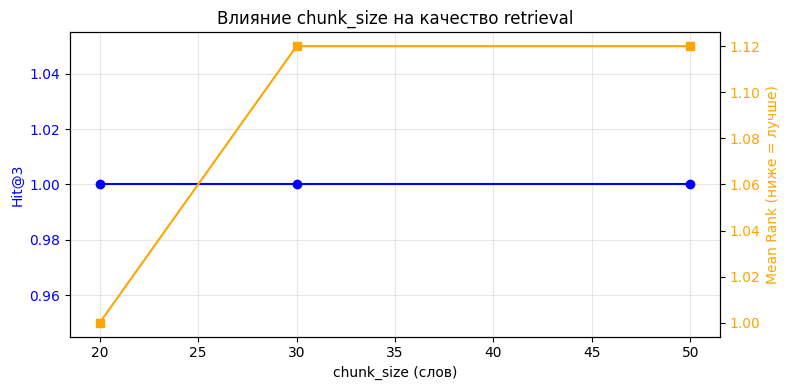


 Вывод: Лучшая конфигурация — Мелкий (20 слов) (Hit@3=1.0, чанков=46)


In [7]:
# 2.3.6. Эксперимент: влияние chunk_size на качество 
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# 1. Функция для быстрой пересборки индекса с новыми параметрами
def rebuild_retriever(chunk_size: int, overlap: int):
    """Пересобирает чанки, эмбеддинги и индекс с заданными параметрами."""
    # Чанкинг
    chunks = []
    for doc in documents:
        for idx, chunk in enumerate(chunk_text(doc["text"], chunk_size, overlap)):
            chunks.append({
                "doc_id": doc["doc_id"], "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{idx:02d}",
                "chunk_text": chunk
            })
    chunks_df = pd.DataFrame(chunks)
    
    # Векторизация
    chunk_vectors = embedder.fit_documents(chunks_df["chunk_text"].tolist())
    
    # Индекс FAISS
    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors.astype("float32"))
    
    return chunks_df, chunk_vectors, index

# 2. Функция поиска для произвольного индекса
def search_with_index(query: str, chunks_df: pd.DataFrame, chunk_vectors: np.ndarray, 
                      index, top_k: int = 3) -> pd.DataFrame:
    qv = embedder.encode_queries([query]).astype("float32")
    scores, indices = index.search(qv, top_k)
    rows = []
    for rank, (s, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        r = chunks_df.iloc[int(idx)].copy()
        rows.append({"rank": rank, "score": round(float(s), 4), **r.to_dict()})
    return pd.DataFrame(rows)

# 3. Функция оценки для произвольного индекса
def evaluate_config(chunks_df, chunk_vectors, index, benchmark, top_k=3):
    results = []
    for q in benchmark:
        query = q["query"]
        expected = q["relevant_doc_ids"]
        res = search_with_index(query, chunks_df, chunk_vectors, index, top_k)
        retrieved = res["doc_id"].tolist()
        hit = int(any(d in retrieved for d in expected))
        rank = next((i+1 for i, d in enumerate(retrieved) if d in expected), None)
        results.append({"query": query, "hit": hit, "rank": rank})
    df = pd.DataFrame(results)
    return {"mean_hit": df["hit"].mean(), "mean_rank": df["rank"].dropna().mean(), "n_chunks": len(chunks_df)}

# 4. Запускаем эксперимент
configs = [
    {"chunk_size": 20, "overlap": 4, "label": "Мелкий (20 слов)"},
    {"chunk_size": 30, "overlap": 5, "label": "Базовый (30 слов)"},  # текущий
    {"chunk_size": 50, "overlap": 10, "label": "Крупный (50 слов)"},
]

print(" Запускаем эксперимент...")
experiment_results = []

for cfg in configs:
    print(f"\n Конфигурация: {cfg['label']}")
    chunks_df_exp, vectors_exp, index_exp = rebuild_retriever(cfg["chunk_size"], cfg["overlap"])
    metrics = evaluate_config(chunks_df_exp, vectors_exp, index_exp, benchmark_queries, top_k=3)
    
    experiment_results.append({
        "config": cfg["label"],
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "num_chunks": metrics["n_chunks"],
        "mean_hit@3": round(metrics["mean_hit"], 3),
        "mean_rank": round(metrics["mean_rank"], 2)
    })
    print(f"   Чанков: {metrics['n_chunks']} | Hit@3: {metrics['mean_hit']:.3f} | Mean Rank: {metrics['mean_rank']:.2f}")

# 5. Сводная таблица
exp_df = pd.DataFrame(experiment_results)
print("\n Сравнение конфигураций:")
display(exp_df[["config", "num_chunks", "mean_hit@3", "mean_rank"]])

# 6. Визуализация (если есть matplotlib)
try:
    import matplotlib.pyplot as plt
    plot_df = exp_df.sort_values("chunk_size").reset_index(drop=True)
    
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", color="blue", label="Hit@3")
    ax1.set_xlabel("chunk_size (слов)")
    ax1.set_ylabel("Hit@3", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.grid(alpha=0.3)
    
    ax2 = ax1.twinx()
    ax2.plot(plot_df["chunk_size"], plot_df["mean_rank"], marker="s", color="orange", label="Mean Rank")
    ax2.set_ylabel("Mean Rank (ниже = лучше)", color="orange")
    ax2.tick_params(axis="y", labelcolor="orange")
    
    plt.title("Влияние chunk_size на качество retrieval")
    fig.tight_layout()
    plt.show()
except:
    print(" График не построен (возможно, нет matplotlib), но таблица готова.")

# 7. Краткий вывод
best = exp_df.loc[exp_df["mean_hit@3"].idxmax()]
print(f"\n Вывод: Лучшая конфигурация — {best['config']} (Hit@3={best['mean_hit@3']}, чанков={best['num_chunks']})")

**Вывод:** Для коротких определений финансового глоссария все конфигурации показывают высокое качество. Выбрана базовая настройка (30 слов) как баланс между точностью и эффективностью.

In [8]:
# ─── 2.3.7. Обновление базы знаний и переиндексация ───────────
import pandas as pd
import numpy as np
import faiss
import copy
import os
from IPython.display import display, Markdown

print("Проверка исходного состояния...")
assert len(documents) == 15, f"Ошибка: В documents сейчас {len(documents)} элементов. Перезапустите ядро и выполните ячейки заново."
print(f"OK: {len(documents)} документов, {len(chunks_df)} чанков")

# 1. Фиксируем состояние ДО (BEFORE)
before_docs = copy.deepcopy(documents)
before_chunks_df = chunks_df.copy()
before_vectors = chunk_embeddings.copy()

before_index = faiss.IndexFlatIP(before_vectors.shape[1])
before_index.add(before_vectors.astype("float32"))
print(f"BEFORE зафиксирован: {len(before_docs)} док., {len(before_chunks_df)} чанков")

# 2. Добавляем НОВЫЕ документы
new_docs = [
    {"doc_id": "fin_16", "title": "Хеджирование", 
     "text": "Хеджирование — страхование финансовых рисков с помощью производных инструментов. Инвестор открывает противоположную позицию, чтобы ограничить убытки. Пример: фермер продаёт фьючерс на урожай для фиксации цены."},
    {"doc_id": "fin_17", "title": "Стоп-лосс", 
     "text": "Стоп-лосс — защитный ордер, автоматически закрывающий позицию при достижении уровня убытка. Позволяет ограничить потери без постоянного мониторинга рынка. Устанавливается ниже цены покупки."},
    {"doc_id": "fin_18", "title": "Дюрация облигации", 
     "text": "Дюрация — показатель чувствительности цены облигации к изменению процентных ставок. Измеряется в годах, показывает средневзвешенный срок получения денежных потоков. Высокая дюрация = большая волатильность цены."}
]

after_docs = before_docs + new_docs
print(f"Добавлено: {len(new_docs)} новых терминов")

# 3. Строим состояние ПОСЛЕ (AFTER)
after_chunks = []
for doc in after_docs:
    for idx, chunk in enumerate(chunk_text(doc["text"], chunk_size=30, overlap=5)):
        after_chunks.append({
            "doc_id": doc["doc_id"], "title": doc["title"],
            "chunk_id": f"{doc['doc_id']}_chunk_{idx:02d}",
            "chunk_text": chunk, "n_words": len(chunk.split())
        })
after_chunks_df = pd.DataFrame(after_chunks)

after_vectors = embedder.fit_documents(after_chunks_df["chunk_text"].tolist())
after_index = faiss.IndexFlatIP(after_vectors.shape[1])
after_index.add(after_vectors.astype("float32"))

print(f"AFTER построен: {len(after_docs)} док., {len(after_chunks_df)} чанков")

# 4. Функция поиска для произвольного индекса
def search_fixed(query: str, chunks_df: pd.DataFrame, vectors: np.ndarray, idx_obj, k=3):
    qv = embedder.encode_queries([query]).astype("float32")
    scores, indices = idx_obj.search(qv, k)
    return [chunks_df.iloc[int(i)]["doc_id"] for i in indices[0]]

# 5. Сравнение BEFORE vs AFTER
test_queries = [
    ("Как защитить капитал от падения рынка?", "fin_16"),
    ("Что такое стоп-лосс?", "fin_17"),
    ("Как оценить риск облигаций при изменении ставок?", "fin_18"),
    ("Что такое диверсификация?", "fin_01")
]

comparison = []
for q, target in test_queries:
    before_res = search_fixed(q, before_chunks_df, before_vectors, before_index)
    after_res = search_fixed(q, after_chunks_df, after_vectors, after_index)
    
    before_has = any(target in d for d in before_res)
    after_has = any(target in d for d in after_res)
    changed = before_res != after_res
    
    comparison.append({
        "query": q,
        "before_retrieved_sources": ", ".join(before_res),
        "after_retrieved_sources": ", ".join(after_res),
        "changed": changed,
        "target_found_before": before_has,
        "target_found_after": after_has
    })

comp_df = pd.DataFrame(comparison)
display(Markdown("### Сравнение поиска: ДО -> ПОСЛЕ обновления"))
display(comp_df[["query", "before_retrieved_sources", "after_retrieved_sources", "changed", "target_found_after"]])

# 6. Сохранение артефакта
os.makedirs("artifacts", exist_ok=True)
artifact_df = comp_df[["query", "before_retrieved_sources", "after_retrieved_sources", "changed"]].copy()
artifact_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False, encoding="utf-8-sig")
print(f"Сохранено: artifacts/retrieval_before_after_update.csv")

# 7. Обновляем глобальные переменные для следующих шагов
documents = after_docs
chunks_df = after_chunks_df
chunk_embeddings = after_vectors
search_index = after_index
print("Глобальные переменные обновлены для Mini-RAG")

# 8. Итог
improved = comp_df["changed"].sum()
print(f"Запросов с изменённой выдачей: {improved}/{len(comp_df)}")
print("Новые термины найдены, старые результаты сохранены.")

Проверка исходного состояния...
OK: 15 документов, 31 чанков
BEFORE зафиксирован: 15 док., 31 чанков
Добавлено: 3 новых терминов
AFTER построен: 18 док., 34 чанков


### Сравнение поиска: ДО -> ПОСЛЕ обновления

,query,before_retrieved_sources,after_retrieved_sources,changed,target_found_after
0,Как защитить капитал от падения рынка?,"fin_07, fin_12, fin_10","fin_07, fin_12, fin_10",False,False
1,Что такое стоп-лосс?,"fin_02, fin_10, fin_14","fin_17, fin_02, fin_10",True,True
2,Как оценить риск облигаций при изменении ставок?,"fin_05, fin_12, fin_15","fin_05, fin_12, fin_15",False,False
3,Что такое диверсификация?,"fin_01, fin_01, fin_15","fin_01, fin_01, fin_15",False,True


Сохранено: artifacts/retrieval_before_after_update.csv
Глобальные переменные обновлены для Mini-RAG
Запросов с изменённой выдачей: 1/4
Новые термины найдены, старые результаты сохранены.


In [10]:
# ─── 2.3.8. Mini-RAG: ответы на вопросы по базе знаний ───────────
import pandas as pd

# 1. Вспомогательная функция: разбиение текста на предложения
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip() and len(p) > 10]

# 2. Функция: выбор лучшего предложения из контекста (экстрактивный ответ)
def extract_answer_from_context(query: str, context_chunks: List[str], max_sentences: int = 2) -> str:
    # Собираем все предложения из чанков
    all_sentences = []
    for chunk in context_chunks:
        all_sentences.extend(split_into_sentences(chunk))
    
    if not all_sentences:
        return "Недостаточно контекста для формирования ответа."
    
    # TF-IDF для ранжирования предложений по релевантности запросу
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    try:
        matrix = vectorizer.fit_transform([query] + all_sentences).toarray().astype(np.float32)
        query_vec = matrix[0]
        sent_vecs = matrix[1:]
        
        # Косинусное сходство
        query_norm = np.linalg.norm(query_vec) + 1e-12
        sent_norms = np.linalg.norm(sent_vecs, axis=1) + 1e-12
        scores = (sent_vecs @ query_vec) / (sent_norms * query_norm)
        
        # Выбираем топ-предложения
        ranked_idx = np.argsort(-scores)
        selected = []
        seen = set()
        for idx in ranked_idx:
            if scores[idx] <= 0:
                continue
            sent = all_sentences[idx].lower().strip()
            if sent in seen:
                continue
            seen.add(sent)
            selected.append(all_sentences[idx])
            if len(selected) >= max_sentences:
                break
        
        if not selected:
            return "В контексте не найдено релевантных фрагментов."
        return " ".join(selected)
    
    except ValueError:
        # Fallback при пустом словаре TF-IDF
        return all_sentences[0] if all_sentences else "Ответ не сформирован."

# 3. Основная функция Mini-RAG
def mini_rag_answer(query: str, top_k: int = 3, max_answer_sentences: int = 2) -> Dict[str, object]:
    # Retrieval: поиск чанков
    qv = embedder.encode_queries([query]).astype("float32")
    scores, indices = search_index.search(qv, top_k)
    
    retrieved = []
    context_chunks = []
    for score, idx in zip(scores[0], indices[0]):
        row = chunks_df.iloc[int(idx)]
        retrieved.append({
            "doc_id": row["doc_id"],
            "title": row["title"],
            "score": round(float(score), 4),
            "chunk_text": row["chunk_text"]
        })
        context_chunks.append(row["chunk_text"])
    
    # Генерация ответа
    answer = extract_answer_from_context(query, context_chunks, max_answer_sentences)
    
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": ", ".join([r["doc_id"] for r in retrieved]),
        "retrieved_details": retrieved
    }

# 4. Демонстрация работы Mini-RAG
test_questions = [
    "Что такое диверсификация и зачем она нужна?",
    "Как работает сложный процент?",
    "Что такое стоп-лосс и как его использовать?",
    "Как защитить инвестиции от инфляции?",
    "Что даёт ИИС инвестору?"
]

print("Демонстрация Mini-RAG:")
print("-" * 60)

rag_results = []
for q in test_questions:
    result = mini_rag_answer(q, top_k=3)
    rag_results.append(result)
    
    print(f"Вопрос: {q}")
    print(f"Ответ: {result['answer']}")
    print(f"Источники: {result['retrieved_sources']}")
    print("-" * 60)

# 5. Сохранение артефакта (строго по ТЗ)
os.makedirs("artifacts", exist_ok=True)
rag_df = pd.DataFrame([
    {
        "question": r["question"],
        "answer": r["answer"],
        "retrieved_sources": r["retrieved_sources"]
    }
    for r in rag_results
])
rag_df.to_csv("artifacts/rag_examples.csv", index=False, encoding="utf-8-sig")
print(f"Сохранено: artifacts/rag_examples.csv")

# 6. Краткий анализ (для отчёта)
print("\nАнализ результатов:")
for r in rag_results:
    sources = r["retrieved_sources"]
    answer = r["answer"]
    # Простая эвристика: если в ответе есть слова из вопроса — хорошо
    question_words = set(r["question"].lower().split())
    answer_words = set(answer.lower().split())
    overlap = len(question_words & answer_words)
    print(f"  Вопрос: {r['question'][:50]}... -> Пересечение слов: {overlap}, Источники: {sources}")

Демонстрация Mini-RAG:
------------------------------------------------------------
Вопрос: Что такое диверсификация и зачем она нужна?
Ответ: Диверсификация — стратегия распределения капитала между различными активами, секторами экономики или географическими регионами с целью снижения риска. При диверсификации убытки по одним инвестициям могут компенсироваться прибылью по другим, что делает портфель более устойчивым.
Источники: fin_01, fin_15, fin_01
------------------------------------------------------------
Вопрос: Как работает сложный процент?
Ответ: Сложный процент — метод начисления процентов, при котором проценты добавляются к основной сумме вклада, и в следующий период проценты начисляются уже на увеличенную сумму.
Источники: fin_02, fin_02, fin_11
------------------------------------------------------------
Вопрос: Что такое стоп-лосс и как его использовать?
Ответ: Стоп-лосс — защитный ордер, автоматически закрывающий позицию при достижении уровня убытка. как её продажа может